In [34]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import os

import sys
sys.path.append('./src/')
from model import NeuralNetwork

In [35]:
x = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/example_input.npy")


In [36]:
print(x*255)

[[  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]
 [  0.]


Dataset loaded: 60000 images, shape 28x28

Instance at index 560:
  Label : 7
  Image shape : (28, 28)
  Pixel range : 0–255


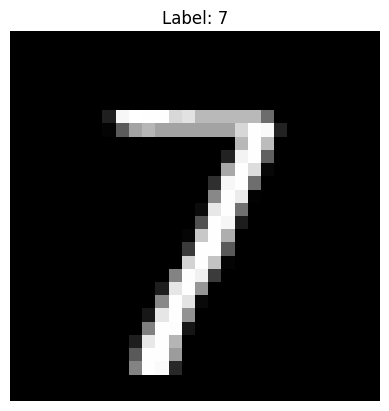

List length : 784
Value range : 0.0000 – 1.0000
First 10    : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [44]:
import struct
import numpy as np
import matplotlib.pyplot as plt


def load_images(filepath):
    """Load MNIST image file in IDX format."""
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number {magic} — expected 2051.")
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images


def load_labels(filepath):
    """Load MNIST label file in IDX format."""
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number {magic} — expected 2049.")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


def get_instance(images, labels, index):
    """Return a single image and its label by index."""
    return images[index], labels[index]


def show_instance(images, labels, index):
    """Display a single MNIST image with its label."""
    image, label = get_instance(images, labels, index)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()
    return image, label


if __name__ == "__main__":
    # ── Configure paths ────────────────────────────────────────────────────────
    IMAGES_PATH = "/Users/omichel/Desktop/qilimanjaro/projects/retech/archive/train-images.idx3-ubyte"   # or .gz unzipped
    LABELS_PATH = "/Users/omichel/Desktop/qilimanjaro/projects/retech/archive/train-labels.idx1-ubyte"
    INDEX = 560                              # change to any index you want
    # ──────────────────────────────────────────────────────────────────────────

    images = load_images(IMAGES_PATH)
    labels = load_labels(LABELS_PATH)

    print(f"Dataset loaded: {images.shape[0]} images, shape {images.shape[1]}x{images.shape[2]}")

    image, label = get_instance(images, labels, INDEX)
    print(f"\nInstance at index {INDEX}:")
    print(f"  Label : {label}")
    print(f"  Image shape : {image.shape}")
    print(f"  Pixel range : {image.min()}–{image.max()}")

    show_instance(images, labels, INDEX)

    pixels = (image.flatten() / 255.0).tolist()

    print(f"List length : {len(pixels)}")
    print(f"Value range : {min(pixels):.4f} – {max(pixels):.4f}")
    print(f"First 10    : {[round(p, 4) for p in pixels[:10]]}")

In [45]:
print(pixels)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12156862745098039, 0.9686274509803922, 1.0, 0.996078431372549, 0.996078431372549, 0.8470588235294118, 0.8862745098039215, 

In [48]:
def main():
    # network dimensions (must match training)
    nn = NeuralNetwork(784, 1000, 1000, 10)

    # load trained weights
    nn.weights_ih1 = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/weights_ih1.npy")
    nn.bias_ih1    = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/bias_ih1.npy")

    nn.weights_h1h2 = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/weights_h1h2.npy")
    nn.bias_h1h2    = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/bias_h1h2.npy")

    nn.weights_h2o = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/weights_h2o.npy")
    nn.bias_h2o    = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/bias_h2o.npy")

    # enable MPO inference (second layer only)
    nn.use_mpo = True
    nn.mpo_ready = False   # force fresh MPO build

    # load ONE input (saved during training)
    data = pixels

    # run inference
    out = nn.feedforward(data)
    pred = np.argmax(out)
    print(out)

    print("Predicted class:", pred)

if __name__ == "__main__":
    main()

[[4.29237308e-06]
 [8.53350009e-05]
 [4.45523430e-03]
 [2.51495512e-02]
 [1.87376411e-04]
 [1.50228172e-04]
 [4.56873258e-07]
 [9.83023046e-01]
 [7.68935131e-05]
 [5.94749252e-03]]
Predicted class: 7


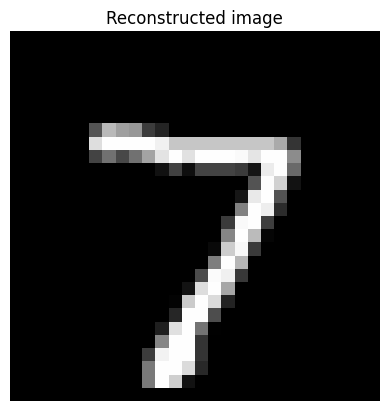

In [ ]:
x = np.load("/Users/omichel/Desktop/qilimanjaro/projects/retech/RETECH_NN_MPO/weights/example_input.npy")

# Reshape to 28x28 and rescale back to 0-255
image = (x.reshape(28, 28) * 255).astype(np.uint8)

# Display
plt.imshow(image, cmap='gray')
plt.title("Reconstructed image")
plt.axis('off')
plt.show()